# Работа 3

**Задача со стрельбой по мишени**

https://habr.com/ru/articles/759994/

В начальный момент времени снаряд стартует из точки $(x_s, y)$ со скоростью $U$. Мишень движется по закону $(x(t), y(t))$. Реализовать поиск направления стрельбы в начальный момент времени чтобы снаряд попал в мишень:

$$
F(t) = | \sqrt{(x(t) - x_s)^2 + (y(t) - y_s)^2} - Ut | \rightarrow \min
$$

1. Для выбранного закона движения мишени визуализировать функцию $F(t)$ и найти ее глобальный минимум

2. Визуализировать попадание при помощи тестового проекта:
   https://github.com/obraz89/TargetShooting


In [21]:
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
U = 8.0
xs, ys = 0, 0


def Position(t):
  """Закон движения мишени"""
  y = 5 * np.sin(0.5 * t) + 10
  x = -3 * t + 10

  return x, y


def F(t):
  """Функция F(t)"""
  x_target, y_target = Position(t)
  distance = np.sqrt((x_target - xs) ** 2 + (y_target - ys) ** 2)
  return abs(distance - U * t)


def CalcShootingDirection(t_guess) -> tuple[tuple, float]:
  """Расчет направления стрельбы по аналитической формуле"""
  x0, y0 = Position(t_guess)

  # Скорость мишени
  dt = 0.01
  x1, y1 = Position(t_guess + dt)
  vx = (x1 - x0) / dt
  vy = (y1 - y0) / dt

  dx = x0 - xs
  dy = y0 - ys

  a = vx**2 + vy**2 - U**2
  b = 2 * (vx * dx + vy * dy)
  c = dx**2 + dy**2

  D = b**2 - 4 * a * c

  if D < 0:
    raise ValueError

  t = (-b - np.sqrt(D)) / (2 * a)

  if t < 0:
    raise ValueError

  # Точка встречи
  x_meet = x0 + vx * t
  y_meet = y0 + vy * t

  # Направление стрельбы
  dir_x = x_meet - xs
  dir_y = y_meet - ys
  length = np.sqrt(dir_x**2 + dir_y**2)

  return (dir_x / length, dir_y / length), t


t0 = 2
(dir_x, dir_y), t = CalcShootingDirection(t0)
x_meet, y_meet = Position(t)


In [23]:
print("Найдено решение:")
print(f"Время: {t:.3f}")
print(f"Направление: ({dir_x:.3f}, {dir_y:.3f})")
print(f"Точка встречи: ({x_meet:.2f}, {y_meet:.2f})")

Найдено решение:
Время: 2.162
Направление: (-0.144, 0.990)
Точка встречи: (3.51, 14.41)


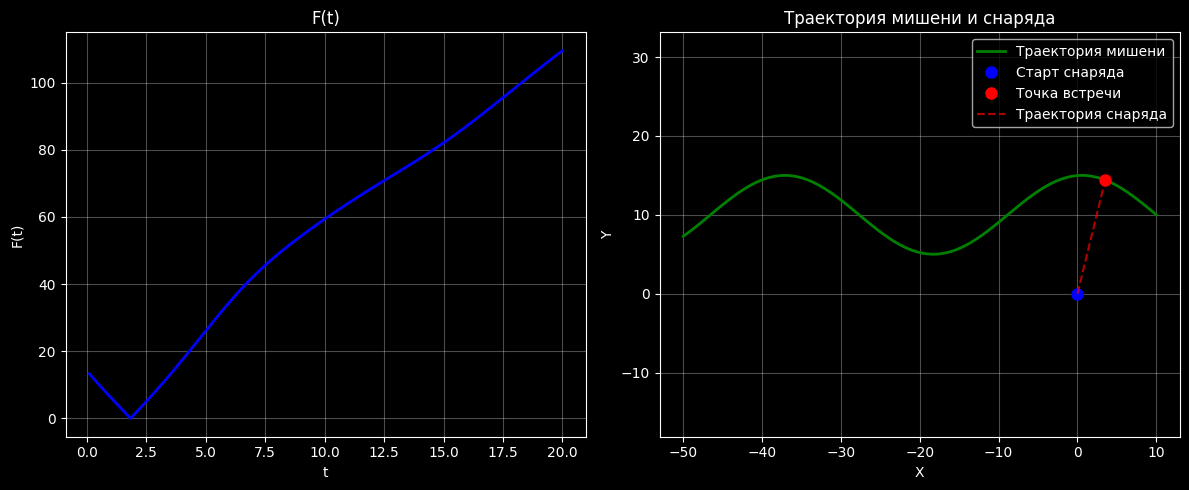

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1. График функции F(t)
t_values = np.linspace(0.1, 20, 1000)
F_values = [F(t_val) for t_val in t_values]

axs[0].plot(t_values, F_values, "b-", linewidth=2)
axs[0].set_xlabel("t")
axs[0].set_ylabel("F(t)")
axs[0].set_title("F(t)")
axs[0].grid(True, alpha=0.3)

# 2. Траектория мишени и снаряда
# Траектория мишени
t_traj = np.linspace(0, 20, 100)
x_traj = [Position(t_val)[0] for t_val in t_traj]
y_traj = [Position(t_val)[1] for t_val in t_traj]

axs[1].plot(x_traj, y_traj, "g-", linewidth=2, label="Траектория мишени")
axs[1].plot(xs, ys, "bo", markersize=8, label="Старт снаряда")
axs[1].plot(x_meet, y_meet, "ro", markersize=8, label="Точка встречи")

# Траектория снаряда
x_shell = np.linspace(xs, x_meet, 50)
y_shell = np.linspace(ys, y_meet, 50)
axs[1].plot(x_shell, y_shell, "r--", alpha=0.7, label="Траектория снаряда")

axs[1].set_xlabel("X")
axs[1].set_ylabel("Y")
axs[1].set_title("Траектория мишени и снаряда")
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].axis("equal")

plt.tight_layout()
plt.show()